In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import abtem
import ase
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve
from skimage.morphology import disk
from scipy.signal.windows import hann
from quantem.core.visualization.custom_normalizations import NormalizationConfig
from matplotlib.patches import Rectangle

def crop_white_border(rgba):
    # Convert to grayscale and find non-white rows/cols
    gray = rgba[..., :3].mean(axis=2)
    mask = gray < 255
    rows = np.any(mask, axis=1)
    cols = np.any(mask, axis=0)
    rmin, rmax = np.where(rows)[0][[0, -1]]
    cmin, cmax = np.where(cols)[0][[0, -1]]
    return rgba[rmin:rmax+1, cmin:cmax+1]

from pathlib import Path

import numpy as np
import torch

import quantem as em
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml import CNN2d
from quantem.core.visualization import show_2d

from importlib.metadata import version # Temporary fix for version check
print(f"quantEM version: {version("quantem")}")

from quantem.core.utils.imaging_utils import detect_bragg_disks, bragg_disks_to_masks

from quantem.diffractive_imaging import (
    PtychographyDatasetRaster,
    DetectorPixelated,
    ObjectDIP,
    ObjectPixelated,
    ProbeDIP,
    ProbePixelated,
    Ptychography,
)

import abtem
import ase

def cmplx_array_to_rgba(cmplx_valued_array, vmin=0.02, vmax=0.98):
    scaled_amplitude = np.abs(cmplx_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = np.angle(cmplx_valued_array)
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase)
    return rgba

def real_array_to_rgba(real_valued_array, vmin=0.02, vmax=0.98, cmap='gray'):
    scaled_amplitude = np.abs(real_valued_array)
    vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
    scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
    scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
    scaled_phase = None
    rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase, cmap=cmap)
    return rgba




quantEM version: 0.1.8


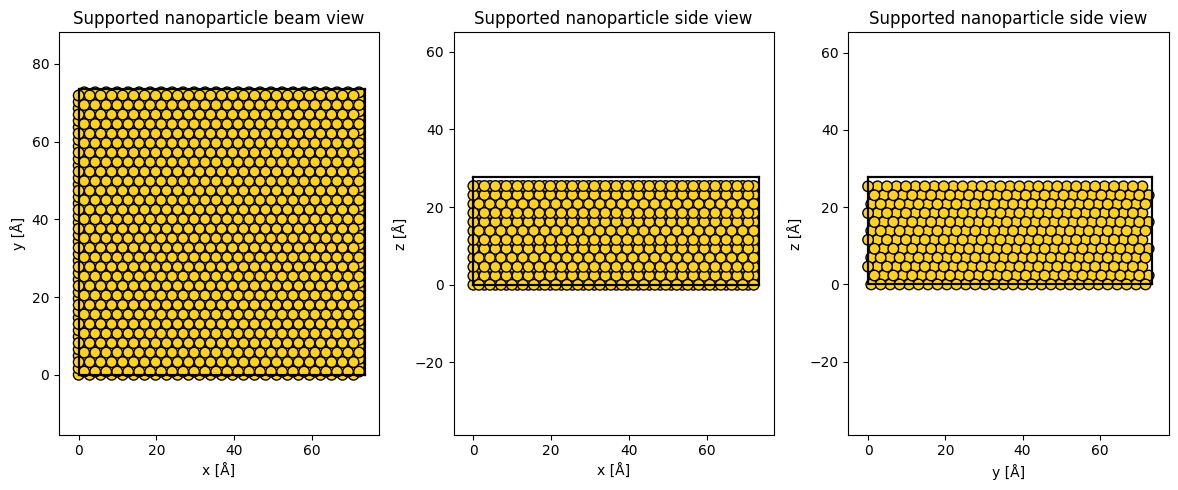

In [3]:
lc = 4
layer_thickness = lc * np.sqrt(3)/3
z_layers = 12
atoms = ase.build.fcc111(
    "Au",
    a = lc,
    size=(1,2,z_layers),
    orthogonal=True,
    periodic=True,
)

atoms *= (26,15,1)
# atoms *= (38,22,1)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))
abtem.show_atoms(
    atoms ,
    ax=ax1,
    title="Supported nanoparticle beam view",
    merge=0.1,
    scale=1,
)
abtem.show_atoms(
    atoms ,
    ax=ax2,
    plane="xz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
abtem.show_atoms(
    atoms ,
    ax=ax3,
    plane="yz",
    scale=1,
    title="Supported nanoparticle side view",
    merge=0.1,
)
fig.tight_layout();

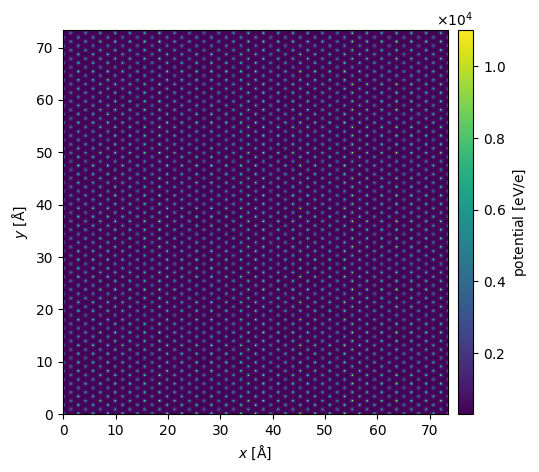

In [4]:
potential = abtem.Potential(
    atoms,
    gpts=(512,512),
    slice_thickness= layer_thickness,
    device='cpu',
    projection='infinite'
).build(
    lazy=False
)

potential.show(
    cbar=True,
    figsize=(6,6)
);

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

tasks:   0%|          | 0/2 [00:00<?, ?it/s]

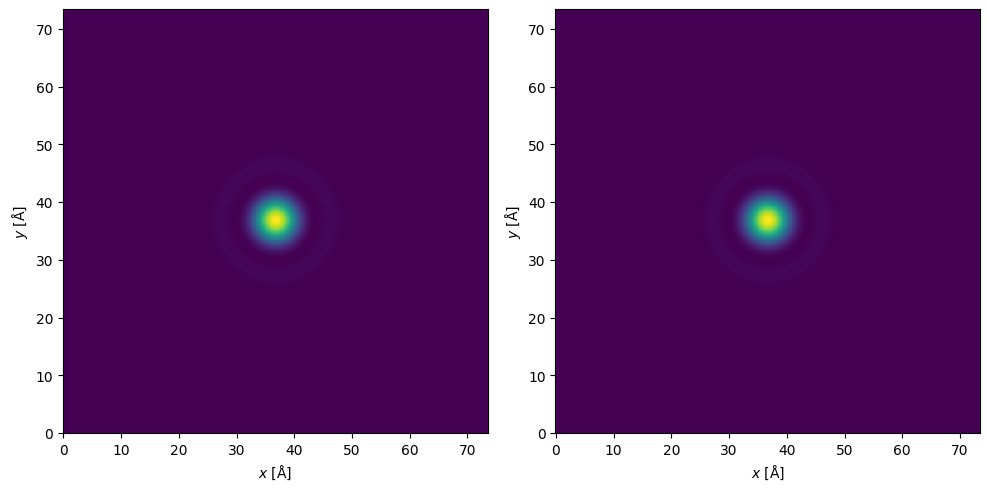

In [5]:
energy = 30e3
# semiangle_cutoff = [8,12,16]
semiangle_cutoff = 6

aberrations = {
    "C10":0,
    # "C12":200,
    # "C21":30000
}

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)

energy2 = 30e3
# semiangle_cutoff = [8,12,16]
semiangle_cutoff2 = 6

aberrations2 = {
    "C10":0,
    # "C12":200,
    # "C21":30000
}

probe2 = abtem.Probe(
    energy=energy2,
    semiangle_cutoff=semiangle_cutoff2,
    aberrations=aberrations2,
    device='cpu',
).match_grid(
    potential
)

fig, axs = plt.subplots(1,2,figsize=(10,5))
probe.show(ax=axs[0],xlim=(1,10))


probe2.show(ax=axs[1])


# probe.build().diffraction_patterns().show(ax=axs[1],explode=True)
fig.tight_layout()



In [6]:
one_third_overlap = 0.51*abtem.core.units.energy2wavelength(energy)/(semiangle_cutoff/1000)/5


In [7]:
start = np.array([0,0])
end = np.array(potential.extent)
gpts = 128

grid_scan = abtem.GridScan(
    start=start,
    end=end,
    gpts=(gpts, gpts),
    endpoint=False
)

detector = abtem.PixelatedDetector(
    max_angle=None
)


In [8]:
gpts

128

In [9]:
measurement = probe.scan(
    potential,
    grid_scan,
    detector,
).compute()

tasks:   0%|          | 0/306 [00:00<?, ?it/s]

In [10]:
dose = 1e3


In [11]:
intensity_measurement_noisy = measurement.crop(gpts=(256,256)).poisson_noise(dose)
dataset_noisy = intensity_measurement_noisy.to_quantem()
dataset_noisy.save(f"/home/wdekleijne/git-repos/willem-playground/data/au_slab_{z_layers}zlayers_{semiangle_cutoff}mrad_{energy/1000:.1e}kev_C10{aberrations["C10"]}_{dose:.0e}dose_gpts{gpts}_256x256.zip",mode='o')

## 6

In [17]:
energy = 30e3
semiangle_cutoff = 6
z_layers = 12
gpts = 61.0
dose = 1e7
gpts=64
aberrations = {
    "C10":0,
    # "C12":200,
    # "C21":30000
}
print(gpts)

filepath_6 = Path(f"/home/wdekleijne/git-repos/willem-playground/data/au_slab_{z_layers}zlayers_{semiangle_cutoff}mrad_{energy/1000:.1e}kev_C10{aberrations["C10"]}_{dose:.0e}dose_gpts{gpts}_256x256.zip")
# filepath = Path(f"/home/wdekleijne/git-repos/willem-playground/data/au_slab_{z_layers}zlayers_28mrad_{energy/1000:.1e}kev_{dose:.0e}dose_gpts173.0_256x256.zip")

dset_6 = em.io.load(filepath_6)

PROBE_ENERGY = energy # eV
PROBE_SEMIANGLE_6 = semiangle_cutoff # mrad
PROBE_DEFOCUS = 0 # A 

64


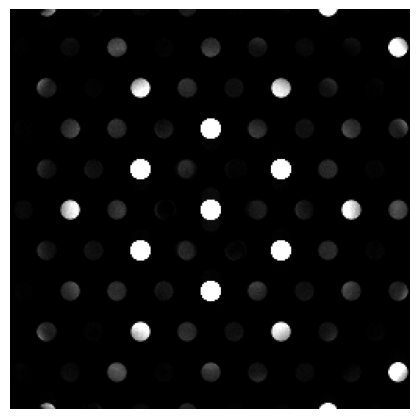

In [18]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(real_array_to_rgba(dset_6.array[2, 1]), interpolation=None)
ax.axis('off')

# scalebar_real = em.visualization.ScalebarConfig(
#     sampling=dset_6.sampling[3],
#     units='$A^{-1}$',
#     length=1
# )
# em.visualization.visualization_utils.add_scalebar_to_ax(
#     ax,
#     dset_6.shape[3],
#     scalebar_real.sampling,
#     scalebar_real.length,
#     scalebar_real.units,
#     scalebar_real.width_px,
#     scalebar_real.pad_px,
#     color='white',
#     loc='lower left'
# )

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

In [88]:
fig.savefig("/home/wdekleijne/git-repos/willem-playground/Papers/Abstract_imc_liverpool/Fig_1_difpattern_6mrad.pdf",bbox_inches='tight')


In [19]:
pdset_6 = PtychographyDatasetRaster.from_dataset4dstem(dset_6)#, wave_ground_truth=dset_wave_ground_truth)
aberrations = {
    "C10":0,
}

probe_params = {
    "energy": PROBE_ENERGY,
    "C10": aberrations["C10"],
    "semiangle_cutoff": PROBE_SEMIANGLE_6,
}

pdset_6.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY,
    com_fit_function='no_shift'
)

obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="complex",
    num_slices=1,
)

probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()

from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography

# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset_6.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix_6 = Ptychography.from_models( 
    dset=pdset_6,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
    #wave_ground_truth=dset_wave_ground_truth,
)

ptycho_pix_6.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/4096 [00:00<?, ?probe position/s]

Missing probe parameter 'defocus' in probe_params


In [ ]:

opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 1e-1, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-2, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 0.0,
        }
}


scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,
    }
}

constraints_stage1 = {
    # "object": {
    #     # "gaussian_sigma": 2.0,      # was "gaussian_filter_sigma" + "gaussian_filter"
    # },
}


ptycho_pix_reconstruct_6 = ptycho_pix_6.reconstruct(
    num_iters=1,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints_stage1, 
    batch_size=1,#16384//64,
    device="cuda:1",
    store_snapshots_every=1,
    autograd=False,
    autograd_random=False,
    disk_phase='disk_phase'
)

ptycho_pix_reconstruct_6.visualize()

em.visualization.show_2d(
    [
        [
            np.rot90(np.angle(ptycho_pix_reconstruct_6.obj[0]),k=1),
        ],
    ],
    title=[
        ["iterative ptychography phase"],
    ],
    axsize=(5,5),
    cbar=True,
    show_ticks=True
    
);


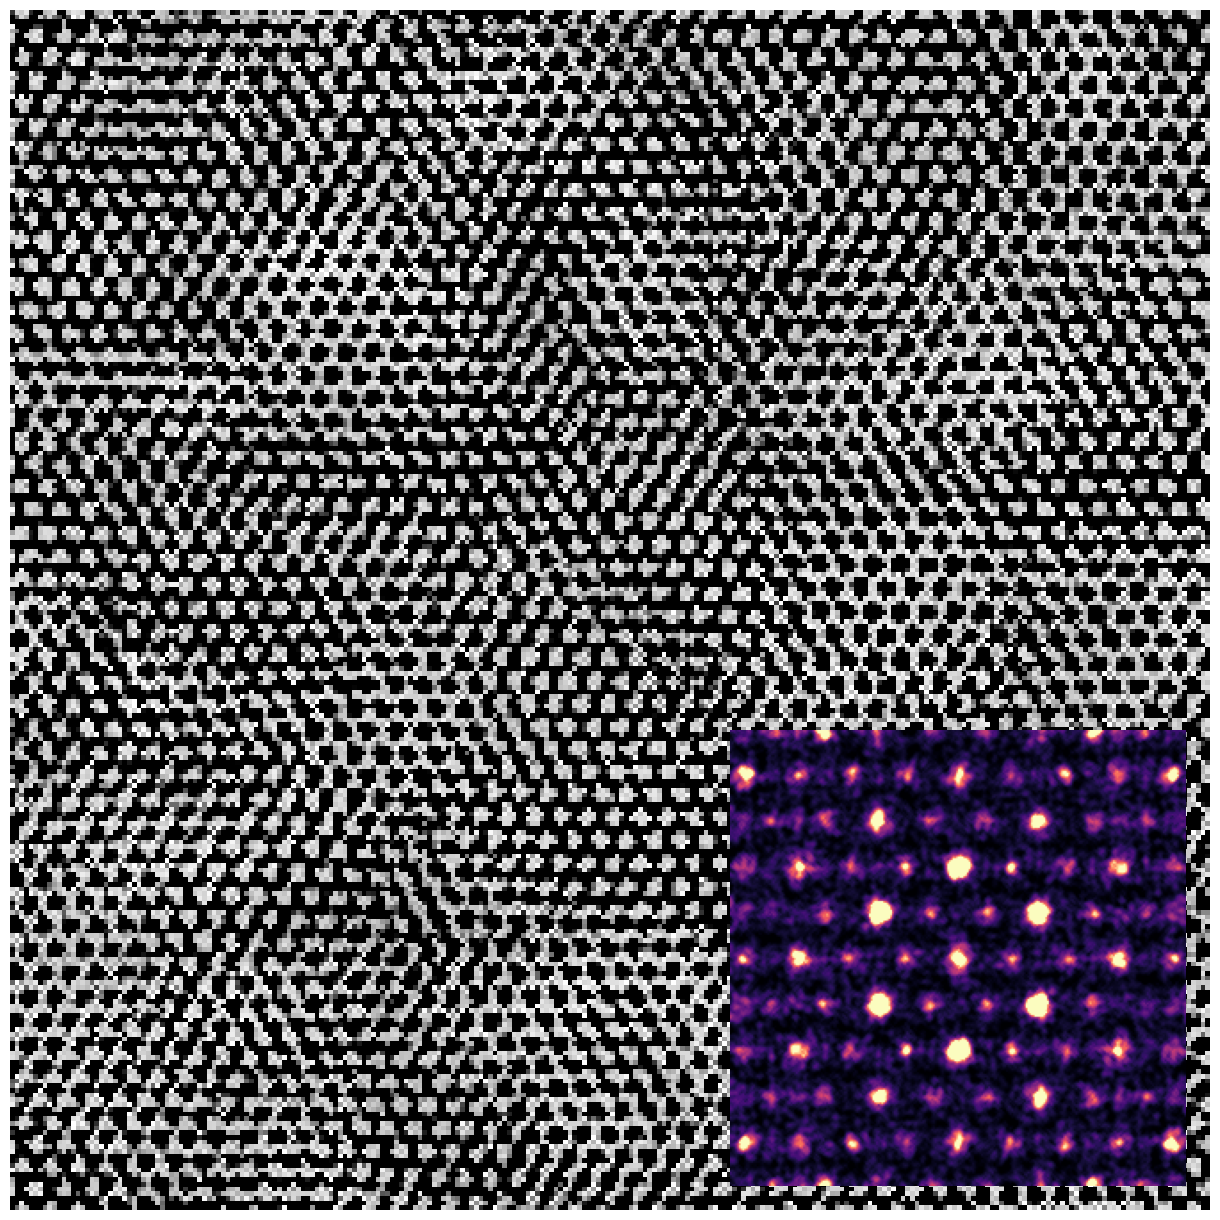

In [23]:
norm_fft = NormalizationConfig(
    interval_type='manual',
    stretch_type='power',
    power=0.5
)

phase = np.angle(ptycho_pix_reconstruct_6.obj[0]).clip(0)

# Build a 2D Hann window
H, W = phase.shape
window = np.outer(hann(H), hann(W))

phase_windowed = phase * window

fft_mag = np.fft.fftshift(np.abs(np.fft.fft2(phase_windowed)))


fft_mag = np.fft.fftshift(np.abs(np.fft.fft2(phase_windowed)))
fft_mag[H//2, W//2] = 0

# Convolve with small disk — increase radius for more spreading
kernel = disk(2).astype(float)
kernel /= kernel.sum()
fft_mag = convolve(fft_mag, kernel)


rgba_main = real_array_to_rgba(phase)
rgba_fft = real_array_to_rgba(fft_mag, cmap='magma')

# Compose the final figure
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(rgba_main,interpolation=None)
ax.axis('off')

# scalebar_real = em.visualization.ScalebarConfig(
#     sampling = ptycho_pix_reconstruct_6.sampling[1],
#     units = 'A',
#     length = 10,
# )

# em.visualization.visualization_utils.add_scalebar_to_ax(
#     ax,
#     ptycho_pix_reconstruct_6.obj[0].shape[1],
#     scalebar_real.sampling,
#     scalebar_real.length,
#     scalebar_real.units,
#     scalebar_real.width_px+2,
#     scalebar_real.pad_px,
#     color='white',
#     loc='lower left',
#     fontsize=26
# )

inset_ax = fig.add_axes([0.60, 0.02, 0.38, 0.38])
inset_ax.imshow(rgba_fft)
inset_ax.axis('off')

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

# scalebar_real = em.visualization.ScalebarConfig(
#     sampling=dset_6.sampling[3],
#     units='$A^{-1}$',
#     length=1
# )
# em.visualization.visualization_utils.add_scalebar_to_ax(
#     inset_ax,
#     dset_6.shape[3],
#     scalebar_real.sampling,
#     scalebar_real.length,
#     scalebar_real.units,
#     scalebar_real.width_px+1,
#     scalebar_real.pad_px,
#     color='white',
#     loc='lower left',
#     fontsize=16
# )


In [86]:
fig.savefig("/home/wdekleijne/git-repos/willem-playground/Papers/Abstract_imc_liverpool/Fig_1_recon_6mrad.pdf",bbox_inches='tight')


## 18

(<Figure size 400x400 with 1 Axes>, <Axes: >)

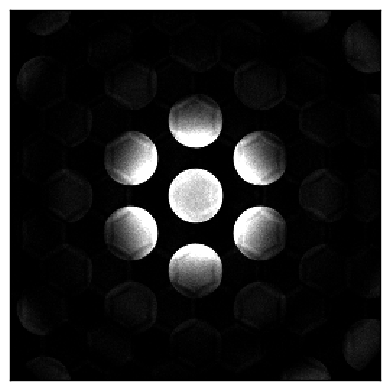

In [8]:
energy = 30e3
semiangle_cutoff = 18
z_layers = 12
dose = 1e7
gpts = 128
aberrations = {
    "C10":300,
}

filepath_18 = Path(f"/home/wdekleijne/git-repos/willem-playground/data/au_slab_{z_layers}zlayers_{semiangle_cutoff}mrad_{energy/1000:.1e}kev_C10{aberrations["C10"]}_{dose:.0e}dose_gpts{gpts}_256x256.zip")
# filepath = Path(f"/home/wdekleijne/git-repos/willem-playground/data/au_slab_{z_layers}zlayers_28mrad_{energy/1000:.1e}kev_{dose:.0e}dose_gpts173.0_256x256.zip")

dset_18= em.io.load(filepath_18)

PROBE_ENERGY = energy # eV
PROBE_SEMIANGLE_18 = semiangle_cutoff # mrad
PROBE_DEFOCUS = aberrations["C10"] # A 




show_2d(dset_18.array[1,2])

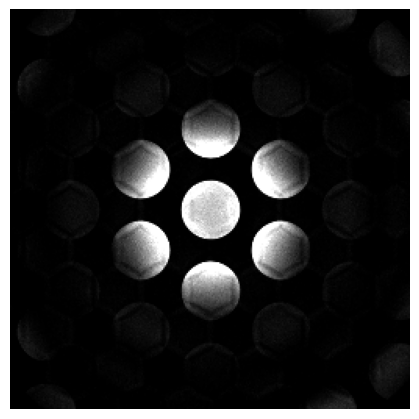

In [9]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(real_array_to_rgba(dset_18.array[2, 1]), interpolation=None)
ax.axis('off')

# scalebar_real = em.visualization.ScalebarConfig(
#     sampling=dset_18.sampling[3],
#     units='$A^{-1}$',
#     length=1
# )
# em.visualization.visualization_utils.add_scalebar_to_ax(
#     ax,
#     dset_18.shape[3],
#     scalebar_real.sampling,
#     scalebar_real.length,
#     scalebar_real.units,
#     scalebar_real.width_px,
#     scalebar_real.pad_px,
#     color='white',
#     loc='lower left'
# )

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

In [111]:
fig.savefig("/home/wdekleijne/git-repos/willem-playground/Papers/Abstract_imc_liverpool/Fig_1_difpattern_18mrad.pdf",bbox_inches='tight')


In [10]:
pdset_18 = PtychographyDatasetRaster.from_dataset4dstem(dset_18)#, wave_ground_truth=dset_wave_ground_truth)


probe_params = {
    "energy": PROBE_ENERGY,
    "C10": aberrations["C10"],
    "semiangle_cutoff": PROBE_SEMIANGLE_18,
}

pdset_18.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY,
    com_fit_function='no_shift'
)
lc = 4
layer_thickness = lc * np.sqrt(3)/3

obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="complex",
    num_slices=1,
    # slice_thicknesses=layer_thickness
)

probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()

from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography

# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset_18.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix_18 = Ptychography.from_models( 
    dset=pdset_18,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
    #wave_ground_truth=dset_wave_ground_truth,
)

ptycho_pix_18.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/16384 [00:00<?, ?probe position/s]

  0%|          | 0/25 [00:00<?, ?it/s]

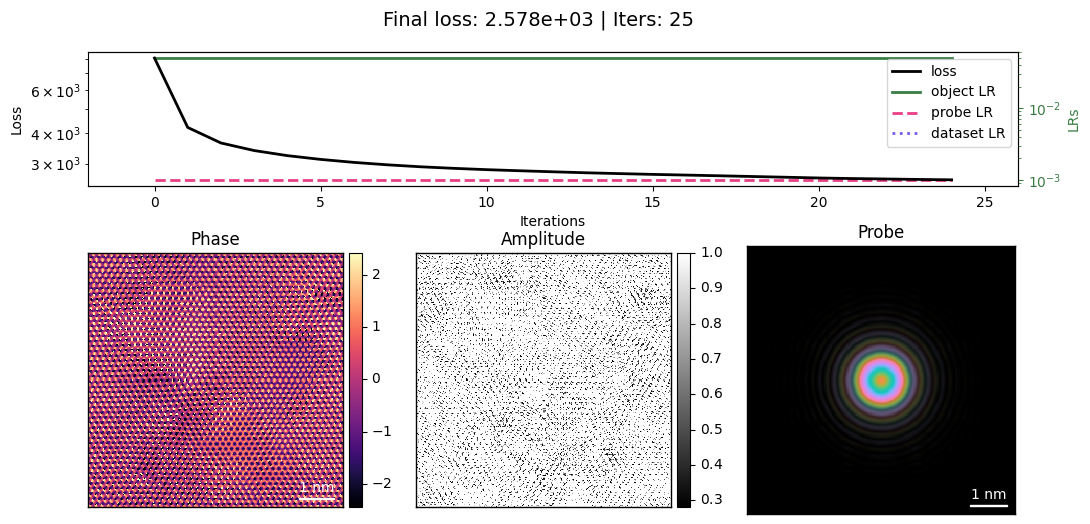

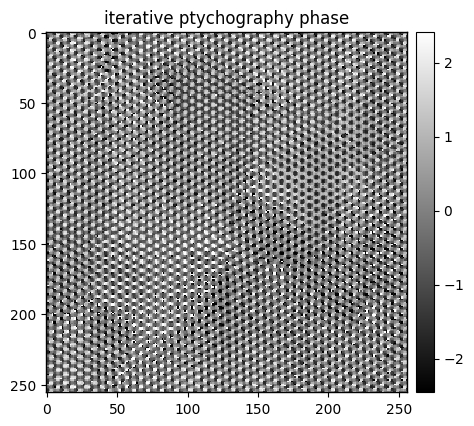

In [14]:

opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 0.5e-1, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 1e-3, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 0.0,
        }
}


scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,
    }
}

constraints_stage1 = {
    # "object": {
    #     # "gaussian_sigma": 2.0,      # was "gaussian_filter_sigma" + "gaussian_filter"
    # },
}


ptycho_pix_reconstruct_18 = ptycho_pix_18.reconstruct(
    num_iters=25,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints_stage1, 
    batch_size=16384//32,
    device="cuda:1",
    store_snapshots_every=1,
    autograd=True,
    autograd_random=False,
    disk_phase='disk_phase'
)

ptycho_pix_reconstruct_18.visualize()

em.visualization.show_2d(
    [
        [
            np.rot90(np.angle(ptycho_pix_reconstruct_18.obj[0]),k=1),
        ],
    ],
    title=[
        ["iterative ptychography phase"],
    ],
    axsize=(5,5),
    cbar=True,
    show_ticks=True
    
);


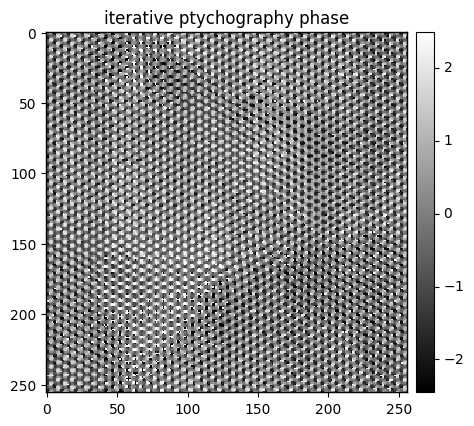

In [18]:
em.visualization.show_2d(
    [
        [
            np.rot90(np.angle(ptycho_pix_reconstruct_18.obj[0]),k=1),
        ],
    ],
    title=[
        ["iterative ptychography phase"],
    ],
    axsize=(5,5),
    cbar=True,
    show_ticks=True
    
);

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

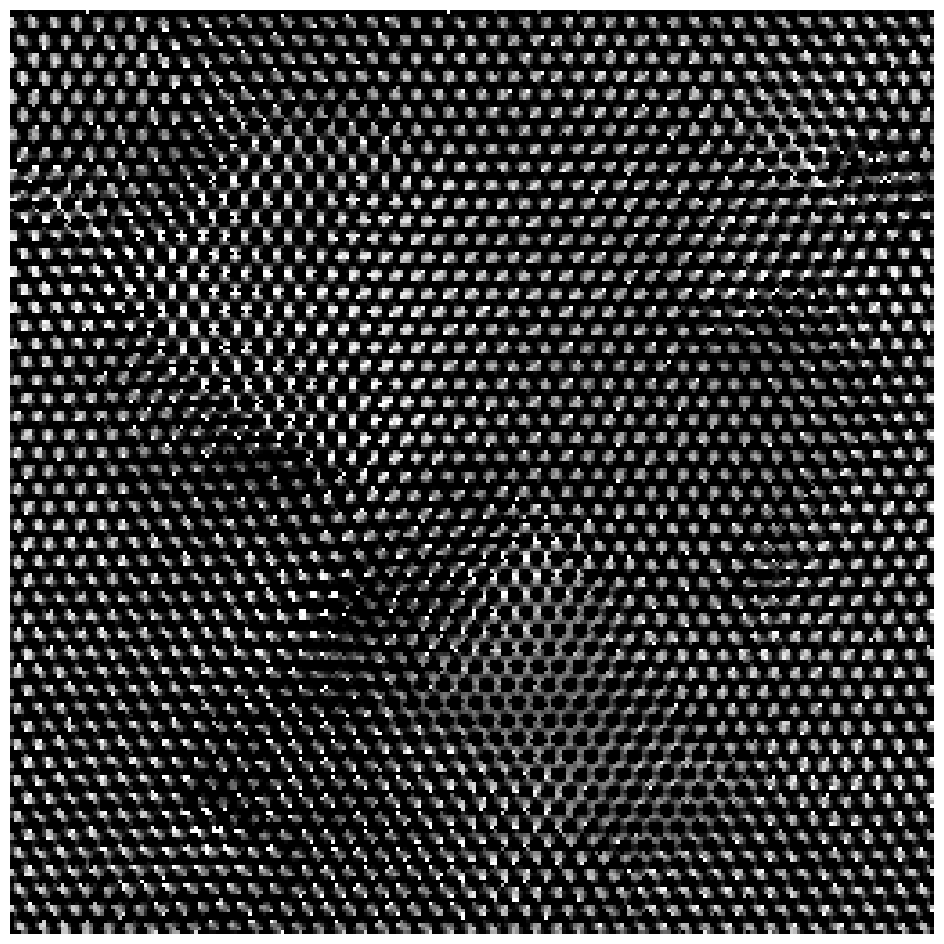

In [ ]:
norm_fft = NormalizationConfig(
    interval_type='manual',
    stretch_type='power',
    power=0.5
)

phase = np.angle(ptycho_pix_reconstruct_18.obj.sum(0)).clip(0)

# Build a 2D Hann window
H, W = phase.shape
window = np.outer(hann(H), hann(W))

phase_windowed = phase * window

fft_mag = np.fft.fftshift(np.abs(np.fft.fft2(phase_windowed)))


fft_mag = np.fft.fftshift(np.abs(np.fft.fft2(phase_windowed)))
fft_mag[H//2, W//2] = 0

# Convolve with small disk — increase radius for more spreading
kernel = disk(2).astype(float)
kernel /= kernel.sum()
fft_mag = convolve(fft_mag, kernel)


rgba_main = real_array_to_rgba(phase)
rgba_fft = real_array_to_rgba(fft_mag, cmap='magma')

# Compose the final figure
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(rgba_main,interpolation=None)
ax.axis('off')

# scalebar_real = em.visualization.ScalebarConfig(
#     sampling = ptycho_pix_reconstruct_18.sampling[1],
#     units = 'A',
#     length = 10,
# )

# em.visualization.visualization_utils.add_scalebar_to_ax(
#     ax,
#     ptycho_pix_reconstruct_18.obj[0].shape[1],
#     scalebar_real.sampling,
#     scalebar_real.length,
#     scalebar_real.units,
#     scalebar_real.width_px+2,
#     scalebar_real.pad_px,
#     color='white',
#     loc='lower left',
#     fontsize=26
# )

inset_ax = fig.add_axes([0.60, 0.02, 0.38, 0.38])
inset_ax.imshow(rgba_fft)
inset_ax.axis('off')

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

# scalebar_real = em.visualization.ScalebarConfig(
#     sampling=dset_18.sampling[3],
#     units='$A^{-1}$',
#     length=1
# )
# em.visualization.visualization_utils.add_scalebar_to_ax(
#     inset_ax,
#     dset_18.shape[3],
#     scalebar_real.sampling,
#     scalebar_real.length,
#     scalebar_real.units,
#     scalebar_real.width_px+1,
#     scalebar_real.pad_px,
#     color='white',
#     loc='lower left',
#     fontsize=16
# )


In [ ]:
fig.savefig("/home/wdekleijne/git-repos/willem-playground/Papers/Abstract_imc_liverpool/Fig_1_recon_18mrad.pdf",bbox_inches='tight')


## 28

(<Figure size 400x400 with 1 Axes>, <Axes: >)

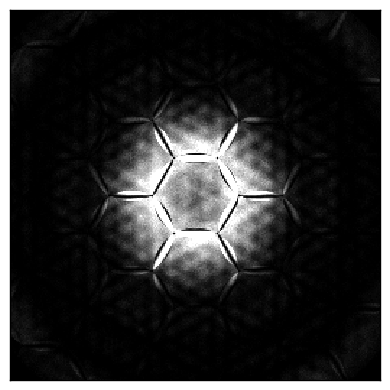

In [3]:
energy = 30e3
semiangle_cutoff = 28
z_layers = 12
dose = 1e7
gpts = 128
aberrations = {
    "C10":200,
}

filepath_28 = Path(f"/home/wdekleijne/git-repos/willem-playground/data/au_slab_{z_layers}zlayers_{semiangle_cutoff}mrad_{energy/1000:.1e}kev_C10{aberrations["C10"]}_{dose:.0e}dose_gpts{gpts}_256x256.zip")
# filepath = Path(f"/home/wdekleijne/git-repos/willem-playground/data/au_slab_{z_layers}zlayers_28mrad_{energy/1000:.1e}kev_{dose:.0e}dose_gpts173.0_256x256.zip")

dset_28= em.io.load(filepath_28)

PROBE_ENERGY = energy # eV
PROBE_SEMIANGLE_28 = semiangle_cutoff # mrad
PROBE_DEFOCUS = aberrations["C10"] # A 




show_2d(dset_28.array[1,2])

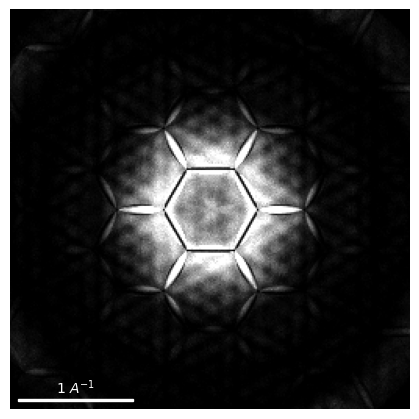

In [7]:
fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(real_array_to_rgba(dset_28.array[0, 0]), interpolation=None)
ax.axis('off')

scalebar_real = em.visualization.ScalebarConfig(
    sampling=dset_28.sampling[3],
    units='$A^{-1}$',
    length=1
)
em.visualization.visualization_utils.add_scalebar_to_ax(
    ax,
    dset_28.shape[3],
    scalebar_real.sampling,
    scalebar_real.length,
    scalebar_real.units,
    scalebar_real.width_px,
    scalebar_real.pad_px,
    color='white',
    loc='lower left'
)

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.show()

In [93]:
fig.savefig("/home/wdekleijne/git-repos/willem-playground/Papers/Abstract_imc_liverpool/Fig_1_difpattern_28mrad.pdf",bbox_inches='tight')


In [16]:
pdset_28 = PtychographyDatasetRaster.from_dataset4dstem(dset_28)#, wave_ground_truth=dset_wave_ground_truth)

probe_params = {
    "energy": PROBE_ENERGY,
    "C10": aberrations["C10"],
    "semiangle_cutoff": PROBE_SEMIANGLE_28,
}

pdset_28.preprocess(
    force_com_rotation=0,
    force_com_transpose=0,
    plot_com=False,
    probe_energy=PROBE_ENERGY,
    com_fit_function='no_shift'
)

obj_model_pix = ObjectPixelated.from_uniform( # also from_array and from_random 
    obj_type="complex",
    num_slices=1,
)

probe_model_pix = ProbePixelated.from_params(
    probe_params=probe_params,
)

detector_model = DetectorPixelated()

from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography

# logger = None
logger_pix = LoggerPtychography(
    log_dir = "./logs",
    run_prefix=dset_28.name,
    run_suffix="pix",
    log_images_every=10,
    log_probe_images=False,
)

ptycho_pix_28 = Ptychography.from_models( 
    dset=pdset_28,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger_pix,
    rng=42,
    #wave_ground_truth=dset_wave_ground_truth,
)

ptycho_pix_28.preprocess(
    obj_padding_px=(0, 0),
    val_ratio=0.0,
)

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to 0.


Normalizing intensities:   0%|          | 0/16384 [00:00<?, ?probe position/s]

  0%|          | 0/125 [00:00<?, ?it/s]

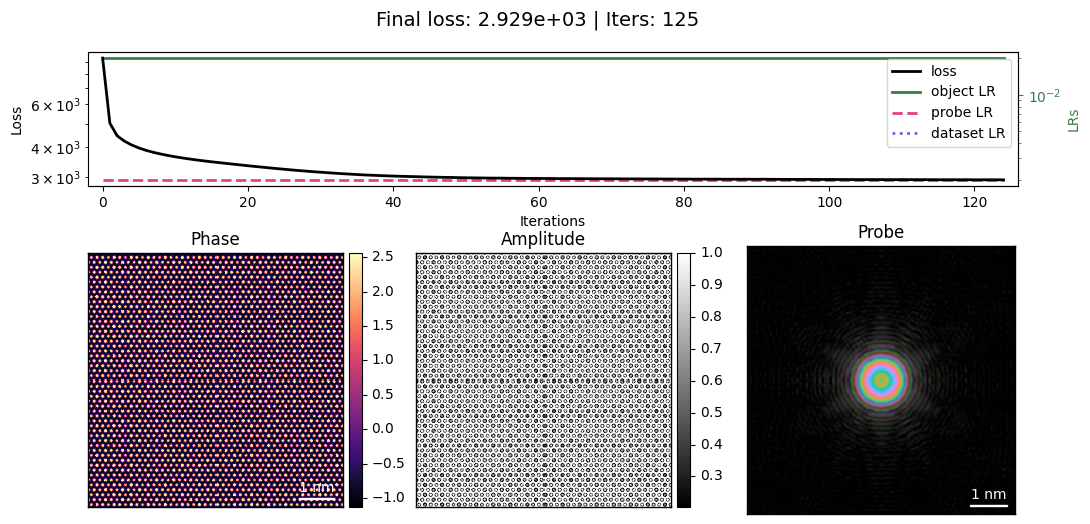

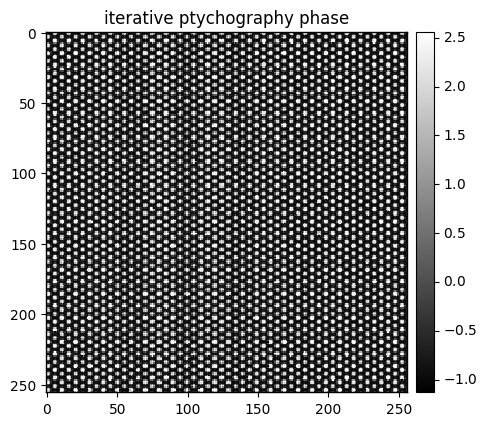

In [17]:

opt_params = {
        "object": {
            "type": "adamw", 
            "lr": 0.2e-1, 
        },
        "probe": {
            "type": "adamw", 
            "lr": 0.2e-2, 
        },
        "dataset": { ### for optimizing over descan shifts and probe positions
            "type": "adamw",
            "lr": 0.0,
        }
}


scheduler_params = {
    "object": { ## scheduler kwargs are passed to the scheduler (of type type)
        "type": "plateau", ## i like plateau for many cases
        "factor":0.2,

    },
    "probe": {
        "type": "plateau",
        "factor":0.2,

    },
    "dataset": { 
        "type": "plateau",  ## exp is also frequently used 
        "factor":0.2,
    }
}

constraints_stage1 = {
    # "object": {
    #     # "gaussian_sigma": 2.0,      # was "gaussian_filter_sigma" + "gaussian_filter"
    # },
}


ptycho_pix_reconstruct_28 = ptycho_pix_28.reconstruct(
    num_iters=125,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    constraints=constraints_stage1, 
    batch_size=16384//32,
    device="cuda:0",
    store_snapshots_every=1,
    autograd=False,
    autograd_random=False,
    disk_phase='disk_phase'
)

ptycho_pix_reconstruct_28.visualize()

em.visualization.show_2d(
    [
        [
            np.rot90(np.angle(ptycho_pix_reconstruct_28.obj[0]),k=1),
        ],
    ],
    title=[
        ["iterative ptychography phase"],
    ],
    axsize=(5,5),
    cbar=True,
    show_ticks=True
    
);


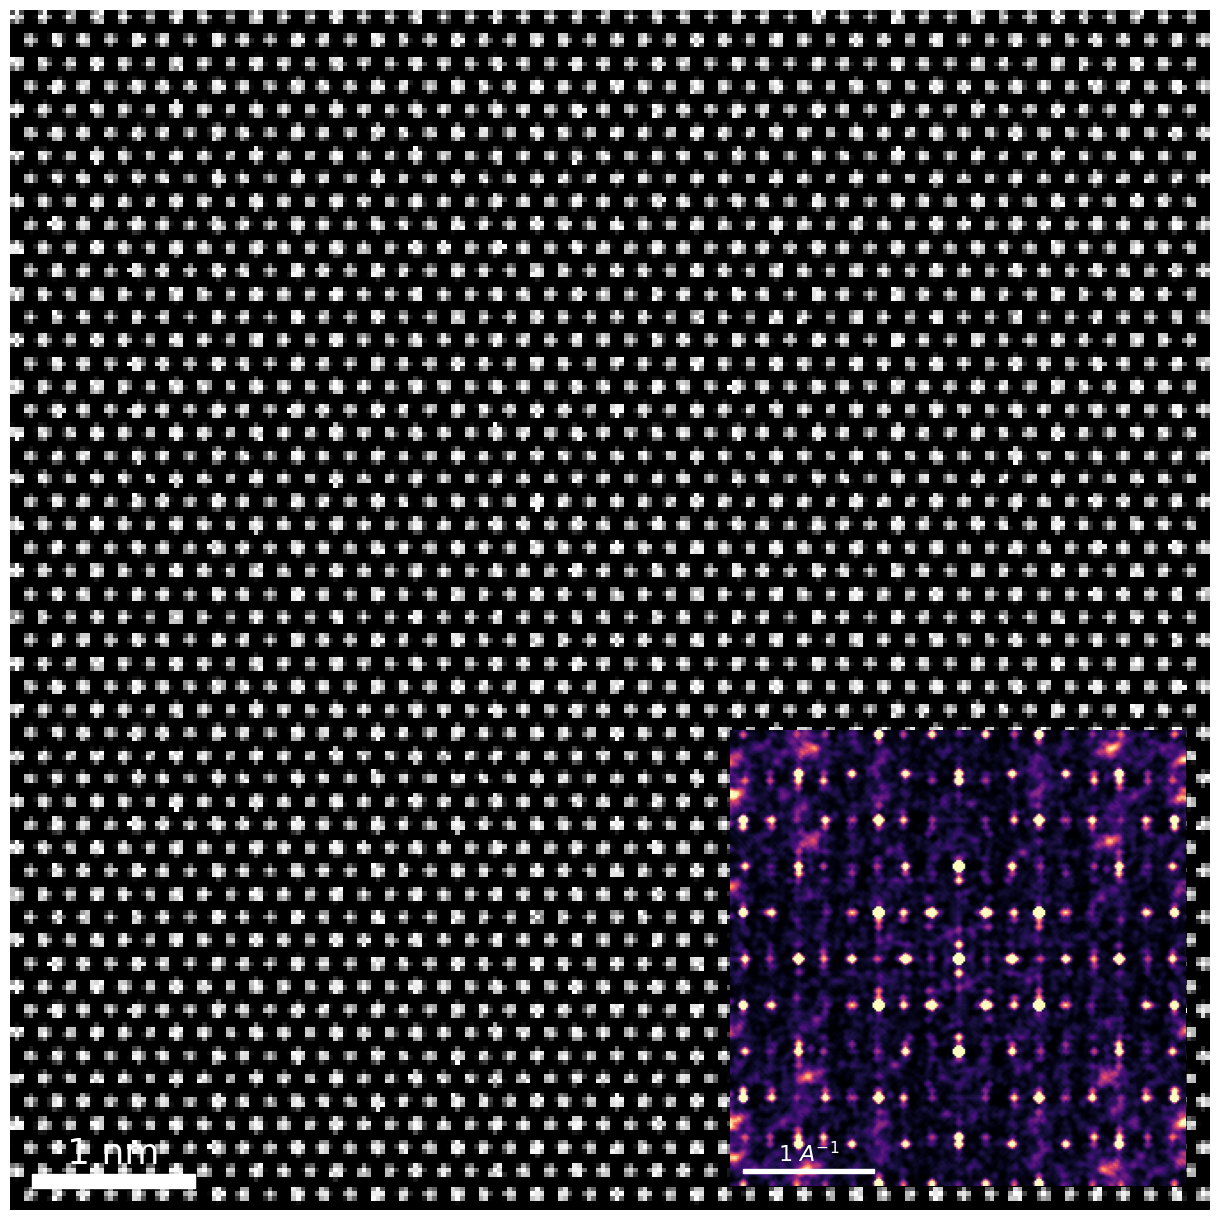

In [83]:
norm_fft = NormalizationConfig(
    interval_type='manual',
    stretch_type='power',
    power=0.5
)

phase = np.angle(ptycho_pix_reconstruct_28.obj[0]).clip(0)

# Build a 2D Hann window
H, W = phase.shape
window = np.outer(hann(H), hann(W))

phase_windowed = phase * window

fft_mag = np.fft.fftshift(np.abs(np.fft.fft2(phase_windowed)))


fft_mag = np.fft.fftshift(np.abs(np.fft.fft2(phase_windowed)))
fft_mag[H//2, W//2] = 0

# Convolve with small disk — increase radius for more spreading
kernel = disk(2).astype(float)
kernel /= kernel.sum()
fft_mag = convolve(fft_mag, kernel)


rgba_main = real_array_to_rgba(phase)
rgba_fft = real_array_to_rgba(fft_mag, cmap='magma')

# Compose the final figure
fig, ax = plt.subplots(figsize=(12, 12))
ax.imshow(rgba_main,interpolation=None)
ax.axis('off')

scalebar_real = em.visualization.ScalebarConfig(
    sampling = ptycho_pix_reconstruct_28.sampling[1],
    units = 'A',
    length = 10,
)

em.visualization.visualization_utils.add_scalebar_to_ax(
    ax,
    ptycho_pix_reconstruct_28.obj[0].shape[1],
    scalebar_real.sampling,
    scalebar_real.length,
    scalebar_real.units,
    scalebar_real.width_px+2,
    scalebar_real.pad_px,
    color='white',
    loc='lower left',
    fontsize=26
)

inset_ax = fig.add_axes([0.60, 0.02, 0.38, 0.38])
inset_ax.imshow(rgba_fft)
inset_ax.axis('off')

fig.subplots_adjust(left=0, right=1, top=1, bottom=0)

scalebar_real = em.visualization.ScalebarConfig(
    sampling=dset_28.sampling[3],
    units='$A^{-1}$',
    length=1
)
em.visualization.visualization_utils.add_scalebar_to_ax(
    inset_ax,
    dset_28.shape[3],
    scalebar_real.sampling,
    scalebar_real.length,
    scalebar_real.units,
    scalebar_real.width_px+1,
    scalebar_real.pad_px,
    color='white',
    loc='lower left',
    fontsize=16
)


In [84]:
fig.savefig("/home/wdekleijne/git-repos/willem-playground/Papers/Abstract_imc_liverpool/Fig_1_recon_28mrad.pdf",bbox_inches='tight')


## Visualization probe on atoms

In [100]:
energy = 30e3
# semiangle_cutoff = [8,12,16]
semiangle_cutoff = 18

aberrations = {
    "C10":300,
    # "C12":200,
    # "C21":30000
}

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)

one_third_overlap = 0.51*abtem.core.units.energy2wavelength(energy)/(semiangle_cutoff/1000)/5

start = np.array([0,0])
end = np.array(potential.extent)
gpts = potential.extent[0]//one_third_overlap
gpts=128
grid_scan = abtem.GridScan(
    start=start,
    end=end,
    gpts=(gpts, gpts),
    endpoint=False
)
cmplx_valued_array = probe.build(lazy=False).array
print(cmplx_valued_array.shape)
print(probe.sampling)
ny, nx = cmplx_valued_array.shape
dx, dy = probe.sampling  # Å per pixel (depends on your library!)

y = (np.arange(ny) - ny // 2) * dy
x = (np.arange(nx) - nx // 2) * dx
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)

r99 = 1 * abtem.core.units.energy2wavelength(energy) / (semiangle_cutoff/1000)  # in Å

mask = R <= r99

masked_probe = cmplx_valued_array * mask

(512, 512)
(0.1436310649285175, 0.14352478961620183)


[11.490485 11.481983]
[11.490485 12.056083]


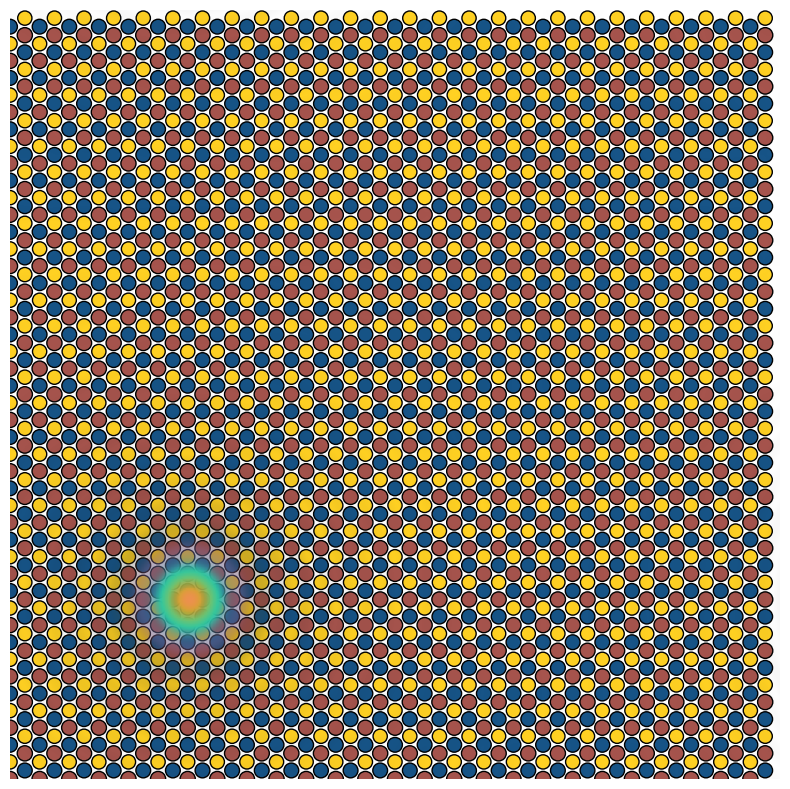

In [101]:

multi_color_atoms = atoms.copy()
layers = np.mod(
    np.round(
        multi_color_atoms.positions[:,2]/ multi_color_atoms.get_cell()[2,2] * 12
    ),
    3
)

layer_0 = multi_color_atoms[layers == 0]
layer_1 = multi_color_atoms[layers == 1]
layer_2 = multi_color_atoms[layers == 2]
layer_0.set_atomic_numbers([77] * len(layer_0))
layer_1.set_atomic_numbers([79] * len(layer_1))
layer_2.set_atomic_numbers([81] * len(layer_2))

multi_color_atoms = layer_0 + layer_1 + layer_2

fig,ax = plt.subplots(figsize=(8,8))
abtem.show_atoms(multi_color_atoms,tight_limits=True,scale=0.5,ax=ax,zorder=-1)

cmplx_valued_array = probe.build(lazy=False).array
# cmplx_valued_array = masked_probe

vmin = 0.0025
vmax = 0.9975
scaled_amplitude = np.abs(cmplx_valued_array)
vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
scaled_phase = np.angle(cmplx_valued_array)

rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase)
rgba[..., 3] = scaled_amplitude




positions = grid_scan.get_positions()[20:40,20:40].reshape((-1,2))
print(positions[0])
print(positions[1])
pixel_to_distance = 512/potential.extent[0]
# ax.imshow(np.roll(rgba, [(potential.extent[1]/2-30*(positions[0,1]-positions[1,1]))*pixel_to_distance, (potential.extent[0]/2-31*(positions[0,1]-positions[1,1]))*pixel_to_distance], axis=(0,1)), extent=[0,potential.extent[0],0,potential.extent[1]], origin='lower')
# ax.imshow(np.roll(rgba, [(potential.extent[1]/2+positions[0,1]-positions[1,1])*pixel_to_distance, potential.extent[0]/2*pixel_to_distance], axis=(0,1)), extent=[0,potential.extent[0],0,potential.extent[1]], origin='lower')
ax.imshow(np.roll(rgba, [(potential.extent[1]/2-30*(positions[0,1]-positions[1,1]))*pixel_to_distance, (potential.extent[0]/2-30*(positions[0,1]-positions[1,1]))*pixel_to_distance], axis=(0,1)), extent=[0,potential.extent[0],0,potential.extent[1]], origin='lower')
ax.axis('off')
# ax.scatter(positions[:,0], positions[:,1], s=1, c='white')
# ax.set_xlim(0, 50)
# ax.set_ylim(0, 50)
fig.tight_layout()
# ax.legend(handles=legend_elements, loc="upper right", fontsize=18)



In [102]:
fig.savefig("/home/wdekleijne/git-repos/willem-playground/Papers/Abstract_imc_liverpool/Fig_1_probeoncrystal_18mrad.pdf",bbox_inches='tight')


In [103]:
energy = 30e3
# semiangle_cutoff = [8,12,16]
semiangle_cutoff = 6

aberrations = {
    "C10":0,
    # "C12":200,
    # "C21":30000
}

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)

one_third_overlap = 0.51*abtem.core.units.energy2wavelength(energy)/(semiangle_cutoff/1000)/5

start = np.array([0,0])
end = np.array(potential.extent)
gpts=128
grid_scan = abtem.GridScan(
    start=start,
    end=end,
    gpts=(gpts, gpts),
    endpoint=False
)

cmplx_valued_array = probe.build(lazy=False).array
print(cmplx_valued_array.shape)
print(probe.sampling)
ny, nx = cmplx_valued_array.shape
dx, dy = probe.sampling  # Å per pixel (depends on your library!)

y = (np.arange(ny) - ny // 2) * dy
x = (np.arange(nx) - nx // 2) * dx
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)

r99 = 1 * abtem.core.units.energy2wavelength(energy) / (semiangle_cutoff/1000)  # in Å

mask = R <= r99

masked_probe = cmplx_valued_array * mask

(512, 512)
(0.1436310649285175, 0.14352478961620183)


[11.490485 11.481983]
[11.490485 12.056083]


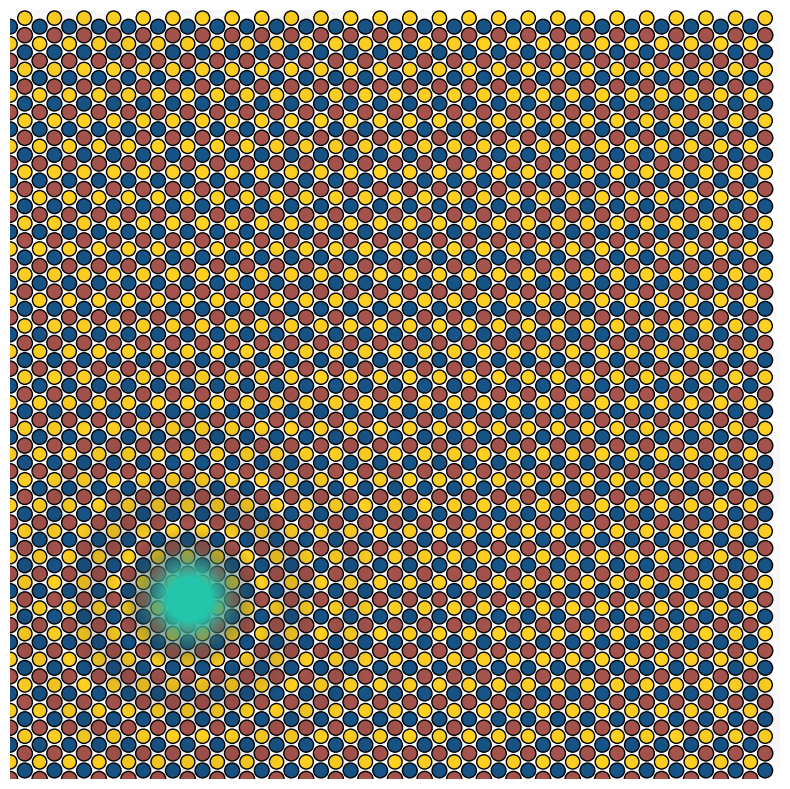

In [105]:
from ase.data import chemical_symbols
from ase.data.colors import jmol_colors
from matplotlib.lines import Line2D

multi_color_atoms = atoms.copy()
layers = np.mod(
    np.round(
        multi_color_atoms.positions[:,2]/ multi_color_atoms.get_cell()[2,2] * 12
    ),
    3
)

layer_0 = multi_color_atoms[layers == 0]
layer_1 = multi_color_atoms[layers == 1]
layer_2 = multi_color_atoms[layers == 2]
layer_0.set_atomic_numbers([77] * len(layer_0))
layer_1.set_atomic_numbers([79] * len(layer_1))
layer_2.set_atomic_numbers([81] * len(layer_2))

multi_color_atoms = layer_0 + layer_1 + layer_2

fig,ax = plt.subplots(figsize=(8,8))
abtem.show_atoms(multi_color_atoms,tight_limits=True,scale=0.5,ax=ax,zorder=-1)

cmplx_valued_array = probe.build(lazy=False).array
# cmplx_valued_array = masked_probe

vmin = 0.0025
vmax = 0.9975
scaled_amplitude = np.abs(cmplx_valued_array)
vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
scaled_phase = np.angle(cmplx_valued_array)

rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase)
rgba[..., 3] = scaled_amplitude




positions = grid_scan.get_positions()[20:40,20:40].reshape((-1,2))
print(positions[0])
print(positions[1])
pixel_to_distance = 512/potential.extent[0]
ax.imshow(np.roll(rgba, [(potential.extent[1]/2-30*(positions[0,1]-positions[1,1]))*pixel_to_distance, (potential.extent[0]/2-30*(positions[0,1]-positions[1,1]))*pixel_to_distance], axis=(0,1)), extent=[0,potential.extent[0],0,potential.extent[1]], origin='lower')
# ax.imshow(np.roll(rgba, [(potential.extent[1]/2+positions[0,1]-positions[1,1])*pixel_to_distance, potential.extent[0]/2*pixel_to_distance], axis=(0,1)), extent=[0,potential.extent[0],0,potential.extent[1]], origin='lower')
# ax.imshow(np.roll(rgba, [(potential.extent[1]/2-20*(positions[0,1]-positions[1,1]))*pixel_to_distance, (potential.extent[0]/2-20*(positions[0,1]-positions[1,1]))*pixel_to_distance], axis=(0,1)), extent=[0,potential.extent[0],0,potential.extent[1]], origin='lower')
layer_names = ["Layer 0", "Layer 1", "Layer 2"]
legend_elements = [
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                markeredgecolor="k",
                label=layer_names[n],
                markerfacecolor=jmol_colors[unique],
                markersize=12,
            )
            for n, unique in enumerate(np.unique([77, 79, 81]))
        ]
ax.axis('off')

# ax.legend(handles=legend_elements, loc="upper right", fontsize=18)
# ax.scatter(positions[:,0], positions[:,1], s=2, c='white')
# ax.set_xlim(0, 50)
# ax.set_ylim(0, 50)
fig.tight_layout()



In [106]:
fig.savefig("/home/wdekleijne/git-repos/willem-playground/Papers/Abstract_imc_liverpool/Fig_1_probeoncrystal_6mrad.pdf",bbox_inches='tight')


In [107]:
energy = 30e3
# semiangle_cutoff = [8,12,16]
semiangle_cutoff = 28

aberrations = {
    "C10":200,
    # "C12":200,
    # "C21":30000
}

probe = abtem.Probe(
    energy=energy,
    semiangle_cutoff=semiangle_cutoff,
    aberrations=aberrations,
    device='cpu',
).match_grid(
    potential
)

one_third_overlap = 0.51*abtem.core.units.energy2wavelength(energy)/(semiangle_cutoff/1000)/3

start = np.array([0,0])
end = np.array(potential.extent)
gpts = potential.extent[0]//one_third_overlap
gpts =128
grid_scan = abtem.GridScan(
    start=start,
    end=end,
    gpts=(gpts, gpts),
    endpoint=False
)

cmplx_valued_array = probe.build(lazy=False).array
print(cmplx_valued_array.shape)
print(probe.sampling)
ny, nx = cmplx_valued_array.shape
dx, dy = probe.sampling  # Å per pixel (depends on your library!)

y = (np.arange(ny) - ny // 2) * dy
x = (np.arange(nx) - nx // 2) * dx
X, Y = np.meshgrid(x, y)

R = np.sqrt(X**2 + Y**2)

r99 = 1 * abtem.core.units.energy2wavelength(energy) / (semiangle_cutoff/1000)  # in Å

mask = R <= r99

masked_probe = cmplx_valued_array * mask

(512, 512)
(0.1436310649285175, 0.14352478961620183)


[11.490485 11.481983]
[11.490485 12.056083]
73.53910524340095


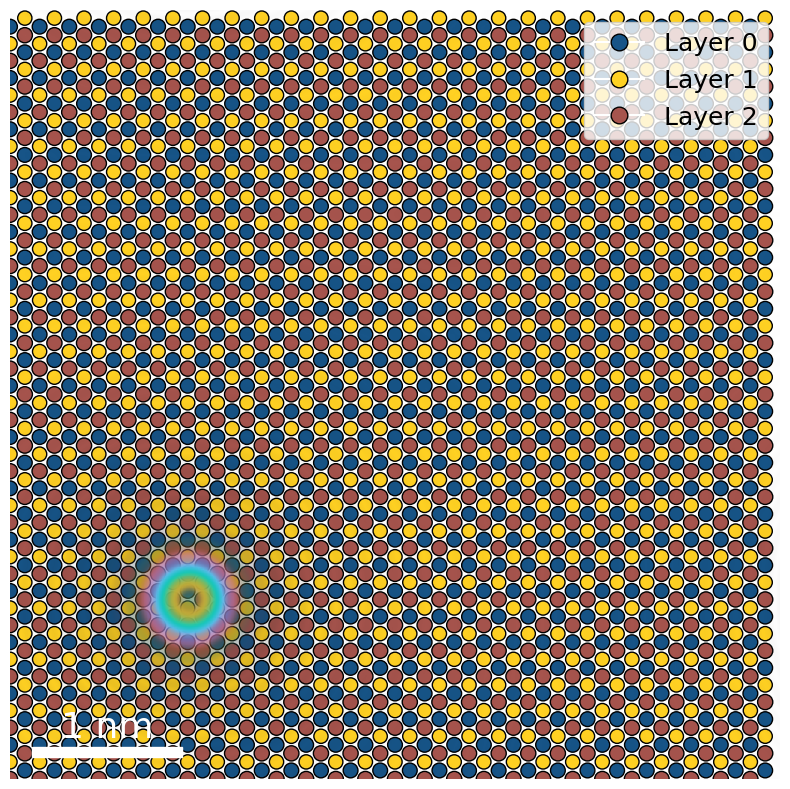

In [108]:

multi_color_atoms = atoms.copy()
layers = np.mod(
    np.round(
        multi_color_atoms.positions[:,2]/ multi_color_atoms.get_cell()[2,2] * 12
    ),
    3
)

layer_0 = multi_color_atoms[layers == 0]
layer_1 = multi_color_atoms[layers == 1]
layer_2 = multi_color_atoms[layers == 2]
layer_0.set_atomic_numbers([77] * len(layer_0))
layer_1.set_atomic_numbers([79] * len(layer_1))
layer_2.set_atomic_numbers([81] * len(layer_2))

multi_color_atoms = layer_0 + layer_1 + layer_2

fig,ax = plt.subplots(figsize=(8,8))
abtem.show_atoms(multi_color_atoms,tight_limits=True,scale=0.5,ax=ax,zorder=-1)

cmplx_valued_array = probe.build(lazy=False).array
# cmplx_valued_array = masked_probe

vmin = 0.0025
vmax = 0.9975
scaled_amplitude = np.abs(cmplx_valued_array)
vmin, vmax = np.quantile(scaled_amplitude, [vmin, vmax])
scaled_amplitude = np.clip(scaled_amplitude, vmin, vmax)
scaled_amplitude = (scaled_amplitude - vmin) / (vmax - vmin)
scaled_phase = np.angle(cmplx_valued_array)

rgba = em.visualization.visualization_utils.array_to_rgba(scaled_amplitude, scaled_phase)
rgba[..., 3] = scaled_amplitude




positions = grid_scan.get_positions()[20:40,20:40].reshape((-1,2))
print(positions[0])
print(positions[1])
pixel_to_distance = 512/potential.extent[0]
# ax.imshow(np.roll(rgba, [(potential.extent[1]/2-30*(positions[0,1]-positions[1,1]))*pixel_to_distance, (potential.extent[0]/2-31*(positions[0,1]-positions[1,1]))*pixel_to_distance], axis=(0,1)), extent=[0,potential.extent[0],0,potential.extent[1]], origin='lower')
ax.imshow(np.roll(rgba, [(potential.extent[1]/2-30*(positions[0,1]-positions[1,1]))*pixel_to_distance, (potential.extent[0]/2-30*(positions[0,1]-positions[1,1]))*pixel_to_distance], axis=(0,1)), extent=[0,potential.extent[0],0,potential.extent[1]], origin='lower')

ax.legend(handles=legend_elements, loc="upper right", fontsize=18)
ax.axis('off')

scalebar_real = em.visualization.ScalebarConfig(
    sampling = pixel_to_distance/10,
    units = 'A',
    length = 10,
)
print(potential.extent[0])
em.visualization.visualization_utils.add_scalebar_to_ax(
    ax,
    pixel_to_distance/10,
    scalebar_real.sampling,
    scalebar_real.length,
    scalebar_real.units,
    scalebar_real.width_px,
    scalebar_real.pad_px,
    color='white',
    loc='lower left',
    fontsize=26
)
# ax.scatter(positions[:,0], positions[:,1], s=1, c='white')
# ax.set_xlim(0, 25)
# ax.set_ylim(0, 25)
fig.tight_layout()



In [109]:
fig.savefig("/home/wdekleijne/git-repos/willem-playground/Papers/Abstract_imc_liverpool/Fig_1_probeoncrystal_28mrad.pdf",bbox_inches='tight')
